# Superior Gradient Boosting Ensemble for PM2.5 Prediction

Optimized to surpass Linear Regression baseline:
- Target: Beat MAE=2.08 (1h), 3.57 (6h), 4.24 (12h), 4.84 (24h)
- Target: Beat R²=0.845 (1h), 0.550 (6h), 0.379 (12h), 0.201 (24h)

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import gc
import psutil
import os
from datetime import datetime
from tqdm import tqdm
warnings.filterwarnings('ignore')

os.environ['OMP_NUM_THREADS'] = '10'
os.environ['MKL_NUM_THREADS'] = '10'
os.environ['OPENBLAS_NUM_THREADS'] = '10'
os.environ['VECLIB_MAXIMUM_THREADS'] = '10'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print(f"Starting M4 Pro Optimized Ensemble: {datetime.now()}")
print(f"Available memory: {psutil.virtual_memory().available / 1e9:.1f} GB")
print(f"CPU cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count()} logical")
print(f"Optimized for Apple Silicon M4 Pro")

Starting M4 Pro Optimized Ensemble: 2025-09-01 18:33:56.852607
Available memory: 13.3 GB
CPU cores: 14 physical, 14 logical
Optimized for Apple Silicon M4 Pro


In [2]:
def get_memory_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9

def optimize_dtypes(df):
    for col in df.columns:
        col_type = df[col].dtype
        
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            continue
        if pd.api.types.is_categorical_dtype(df[col]):
            continue
        if col_type == 'object':
            continue
            
        if pd.api.types.is_float_dtype(df[col]) and col_type != np.float32:
            df[col] = df[col].astype(np.float32)
    
    return df

print(f"Memory utilities loaded. Current: {get_memory_gb():.1f} GB")

Memory utilities loaded. Current: 0.2 GB


## 1. Load Data (Matching Baseline Exactly)

In [3]:
DATA_PATH = '/Users/vojtech/Code/Bard89/smoglens-data/pm25_enriched_2023_2025_v4_20250830_222050.csv'

print("Loading dataset with pyarrow engine...")
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'], engine='pyarrow')
df = df.sort_values(['hex7_id', 'timestamp']).reset_index(drop=True)

print(f"Full dataset: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Total hexagons: {df['hex7_id'].nunique()}")

Loading dataset with pyarrow engine...
Full dataset: (9457112, 39)
Date range: 2023-07-14 16:00:00+00:00 to 2025-07-26 05:00:00+00:00
Total hexagons: 634


## 2. Select High Coverage Hexagons (Same as Baseline)

In [4]:
COVERAGE_THRESHOLD = 0.90
MIN_DURATION_DAYS = 100

coverage_stats = df.groupby('hex7_id').agg({
    'pm25_ugm3_mean': lambda x: x.notna().mean(),
    'timestamp': ['min', 'max']
})
coverage_stats.columns = ['coverage_ratio', 'start_date', 'end_date']
coverage_stats['duration_days'] = (coverage_stats['end_date'] - coverage_stats['start_date']).dt.days

high_coverage_hexagons = coverage_stats[
    (coverage_stats['coverage_ratio'] >= COVERAGE_THRESHOLD) & 
    (coverage_stats['duration_days'] >= MIN_DURATION_DAYS)
].index.tolist()

df = df[df['hex7_id'].isin(high_coverage_hexagons)].copy()
print(f"Selected {len(high_coverage_hexagons)} hexagons with >= {COVERAGE_THRESHOLD:.0%} coverage")
print(f"Filtered dataset: {df.shape}")

Selected 485 hexagons with >= 90% coverage
Filtered dataset: (7320911, 39)


In [5]:
pm25_cap = df['pm25_ugm3_mean'].quantile(0.999)
print(f"Capping PM2.5 at {pm25_cap:.1f} μg/m³")
df['pm25_ugm3_mean'] = df['pm25_ugm3_mean'].clip(upper=pm25_cap)

df['pm25'] = df.groupby('hex7_id')['pm25_ugm3_mean'].transform(
    lambda x: x.interpolate(method='linear', limit=3)
)

df = df.dropna(subset=['pm25'])
df = optimize_dtypes(df)
gc.collect()

print(f"Final dataset: {df.shape}")
print(f"Memory: {get_memory_gb():.1f} GB")

Capping PM2.5 at 53.0 μg/m³
Final dataset: (7241466, 40)
Memory: 5.5 GB


## 3. Enhanced Feature Engineering

In [6]:
df = df.sort_values(['hex7_id', 'timestamp']).reset_index(drop=True)

lag_hours = [1, 2, 3, 4, 5, 6, 12, 24, 48, 72, 168]
print("Creating lag features...")
for lag in tqdm(lag_hours):
    df[f'lag_{lag}h'] = df.groupby('hex7_id')['pm25'].shift(lag).astype('float32')

print("Creating lag differences...")
df['diff_1h'] = (df['pm25'] - df['lag_1h']).astype('float32')
df['diff_6h'] = (df['pm25'] - df['lag_6h']).astype('float32')
df['diff_24h'] = (df['pm25'] - df['lag_24h']).astype('float32')
df['rate_6h'] = (df['diff_6h'] / 6).astype('float32')
df['rate_24h'] = (df['diff_24h'] / 24).astype('float32')

Creating lag features...


100%|██████████| 11/11 [00:01<00:00,  6.10it/s]

Creating lag differences...


In [7]:
print("Creating rolling statistics...")
windows = [3, 6, 12, 24, 48]
for window in tqdm(windows):
    df[f'rolling_mean_{window}h'] = df.groupby('hex7_id')['pm25'].transform(
        lambda x: x.rolling(window, min_periods=window//2).mean()
    ).astype('float32')
    
    df[f'rolling_std_{window}h'] = df.groupby('hex7_id')['pm25'].transform(
        lambda x: x.rolling(window, min_periods=window//2).std()
    ).astype('float32')
    
    df[f'rolling_max_{window}h'] = df.groupby('hex7_id')['pm25'].transform(
        lambda x: x.rolling(window, min_periods=window//2).max()
    ).astype('float32')
    
    df[f'rolling_min_{window}h'] = df.groupby('hex7_id')['pm25'].transform(
        lambda x: x.rolling(window, min_periods=window//2).min()
    ).astype('float32')

print("Creating EWM features...")
for alpha in [0.1, 0.3, 0.5]:
    df[f'ewm_{alpha}'] = df.groupby('hex7_id')['pm25'].transform(
        lambda x: x.ewm(alpha=alpha, adjust=False).mean()
    ).astype('float32')

Creating rolling statistics...


100%|██████████| 5/5 [00:07<00:00,  1.42s/it]


Creating EWM features...


In [8]:
df['hour'] = df['timestamp'].dt.hour.astype('int8')
df['day_of_week'] = df['timestamp'].dt.dayofweek.astype('int8')
df['month'] = df['timestamp'].dt.month.astype('int8')
df['day_of_year'] = df['timestamp'].dt.dayofyear.astype('int16')
df['week_of_year'] = df['timestamp'].dt.isocalendar().week.astype('int8')
df['is_weekend'] = (df['day_of_week'] >= 5).astype('int8')

print("Creating Fourier features with harmonics...")
for k in [1, 2]:
    df[f'hour_sin_{k}'] = np.sin(2 * np.pi * k * df['hour'] / 24).astype('float32')
    df[f'hour_cos_{k}'] = np.cos(2 * np.pi * k * df['hour'] / 24).astype('float32')
    df[f'dow_sin_{k}'] = np.sin(2 * np.pi * k * df['day_of_week'] / 7).astype('float32')
    df[f'dow_cos_{k}'] = np.cos(2 * np.pi * k * df['day_of_week'] / 7).astype('float32')

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12).astype('float32')
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12).astype('float32')

Creating Fourier features with harmonics...


In [9]:
weather_cols = ['temperature_c_mean', 'humidity_pct_mean', 'pressure_hpa_mean', 
                'wind_speed_ms_mean', 'cloud_cover_pct_mean']
traffic_cols = ['avg_traffic_volume', 'congestion_index']

for col in weather_cols + traffic_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median()).astype('float32')

print("Creating interaction features...")
if 'temperature_c_mean' in df.columns and 'humidity_pct_mean' in df.columns:
    df['temp_humidity'] = (df['temperature_c_mean'] * df['humidity_pct_mean'] / 100).astype('float32')
    df['temp_hour'] = (df['temperature_c_mean'] * df['hour_sin_1']).astype('float32')
    
if 'avg_traffic_volume' in df.columns:
    df['traffic_hour'] = (df['avg_traffic_volume'] * df['hour_sin_1']).astype('float32')
    df['traffic_weekend'] = (df['avg_traffic_volume'] * df['is_weekend']).astype('float32')

le_hex = LabelEncoder()
df['hex_encoded'] = le_hex.fit_transform(df['hex7_id']).astype('int16')

print(f"Created {df.shape[1]} total columns")
print(f"Memory: {get_memory_gb():.1f} GB")

Creating interaction features...
Created 94 total columns
Memory: 7.6 GB


## 4. Create Targets and Feature Selection

In [10]:
horizons = [1, 2, 3, 4, 5, 6, 12, 24]
target_cols = []

for h in horizons:
    col_name = f'target_{h}h'
    df[col_name] = df.groupby('hex7_id')['pm25'].shift(-h).astype('float32')
    target_cols.append(col_name)

feature_cols = [
    col for col in df.columns 
    if ('lag_' in col or 'rolling_' in col or 'ewm' in col or
        'diff_' in col or 'rate_' in col or
        '_sin' in col or '_cos' in col or
        'temp_' in col or 'traffic_' in col or
        col in ['hex_encoded', 'is_weekend'] or
        col in weather_cols or col in traffic_cols)
]

feature_cols = [f for f in feature_cols if f in df.columns]
print(f"Selected {len(feature_cols)} features")
print(f"Sample features: {feature_cols[:10]}")

Selected 69 features
Sample features: ['avg_traffic_volume', 'max_traffic_volume', 'congestion_index', 'traffic_measurement_count', 'traffic_distance_km', 'traffic_intensity', 'temperature_c_mean', 'humidity_pct_mean', 'pressure_hpa_mean', 'cloud_cover_pct_mean']


## 5. Train/Test Split (Exact as Baseline)

In [11]:
df = df.dropna(subset=feature_cols + target_cols)
df['year'] = df['timestamp'].dt.year.astype('int16')

train_data = df[df['year'].isin([2023, 2024])].copy()
test_data = df[df['year'] == 2025].copy()

val_size = min(200000, len(train_data) // 10)
val_indices = train_data.groupby('hex7_id', group_keys=False).apply(
    lambda x: x.sample(min(len(x) // 10, val_size // len(high_coverage_hexagons)), random_state=42)
).index

val_data = train_data.loc[val_indices]
train_data = train_data.drop(val_indices)

X_train = train_data[feature_cols]
X_val = val_data[feature_cols]
X_test = test_data[feature_cols]

y_train = {col: train_data[col].values for col in target_cols}
y_val = {col: val_data[col].values for col in target_cols}
y_test = {col: test_data[col].values for col in target_cols}

del df, train_data, val_data, test_data
gc.collect()

print(f"Train: {len(X_train):,} samples")
print(f"Val: {len(X_val):,} samples")
print(f"Test: {len(X_test):,} samples")
print(f"Memory: {get_memory_gb():.1f} GB")

Train: 4,876,256 samples
Val: 198,491 samples
Test: 1,823,502 samples
Memory: 9.3 GB


## 6. Model Parameter Functions

In [12]:
def get_lgb_params(horizon):
    base_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': 127,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'min_child_samples': 10,
        'lambda_l1': 0.1,
        'lambda_l2': 0.1,
        'min_gain_to_split': 0.01,
        'verbose': -1,
        'random_state': 42,
        'n_jobs': -1
    }
    
    if horizon <= 6:
        base_params['num_leaves'] = 255
        base_params['learning_rate'] = 0.03
        base_params['min_child_samples'] = 5
    
    return base_params

def get_xgb_params(horizon):
    base_params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'max_depth': 8,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 5,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'gamma': 0.01,
        'random_state': 42,
        'n_jobs': -1
    }
    
    if horizon <= 6:
        base_params['max_depth'] = 10
        base_params['learning_rate'] = 0.03
        base_params['min_child_weight'] = 3
    
    return base_params

def get_cat_params(horizon):
    base_params = {
        'loss_function': 'RMSE',
        'iterations': 1000,
        'learning_rate': 0.05,
        'depth': 8,
        'l2_leaf_reg': 3,
        'min_data_in_leaf': 10,
        'random_strength': 0.5,
        'bagging_temperature': 0.5,
        'border_count': 128,
        'grow_policy': 'SymmetricTree',
        'random_state': 42,
        'verbose': False,
        'thread_count': -1
    }
    
    if horizon <= 6:
        base_params['depth'] = 10
        base_params['learning_rate'] = 0.03
        base_params['min_data_in_leaf'] = 5
    
    return base_params

## 7. Prepare Data for External Training Script

Save the preprocessed data to disk so the training script can load it.

In [ ]:
print("Saving training data for script...")
X_train.to_pickle('trained/X_train.pkl')
X_val.to_pickle('trained/X_val.pkl')
X_test.to_pickle('trained/X_test.pkl')

import pickle
with open('trained/y_data.pkl', 'wb') as f:
    pickle.dump({'y_train': y_train, 'y_val': y_val, 'y_test': y_test}, f)

with open('trained/metadata.pkl', 'wb') as f:
    pickle.dump({
        'feature_cols': feature_cols,
        'target_cols': target_cols,
        'categorical_features': ['hex_encoded']
    }, f)

print(f"Data saved. Sizes: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

## 8. Execute Training Script

Run the external training script (`train_ensemble.py`) in a subprocess with real-time output streaming.

In [14]:
import os
import json

print("="*70)
print("GRANULAR TRAINING WITH IMMEDIATE SAVES")
print("="*70)
print("\nNEW: Models are saved immediately when they complete!")
print("No lost work if training is interrupted.\n")

print("Option 1: Run GRANULAR script (RECOMMENDED)")
print("-" * 40)
print(f"cd {os.getcwd()}")
print("python train_ensemble_granular.py")
print("✓ Saves each model immediately when complete")
print("✓ Can resume from interruption")
print("✓ CatBoost checkpoints every 200 iterations")

print("\nOption 2: Run M4 optimized script (faster but less safe)")
print("-" * 40)
print(f"cd {os.getcwd()}")
print("python train_ensemble_m4_optimized.py")
print("⚠ Only saves after all 3 models complete")

print("\nOption 3: Run with logging to file")
print("-" * 40)
print(f"cd {os.getcwd()}")
print("python train_ensemble_granular.py 2>&1 | tee training_log.txt")

print("\nOption 4: Run in background")
print("-" * 40) 
print(f"cd {os.getcwd()}")
print("nohup python train_ensemble_granular.py > training_log.txt 2>&1 &")
print("# Then monitor with: tail -f training_log.txt")

print("\n" + "="*70)
print("Check GRANULAR training progress with the next cell")
print("="*70)

GRANULAR TRAINING WITH IMMEDIATE SAVES

NEW: Models are saved immediately when they complete!
No lost work if training is interrupted.

Option 1: Run GRANULAR script (RECOMMENDED)
----------------------------------------
cd /Users/vojtech/Code/Bard89/smoglens-02/voi/V4_enrichement_OPEANAQ_OPENMETEO_JARTIC/05_modeling/V2_advanced
python train_ensemble_granular.py
✓ Saves each model immediately when complete
✓ Can resume from interruption
✓ CatBoost checkpoints every 200 iterations

Option 2: Run M4 optimized script (faster but less safe)
----------------------------------------
cd /Users/vojtech/Code/Bard89/smoglens-02/voi/V4_enrichement_OPEANAQ_OPENMETEO_JARTIC/05_modeling/V2_advanced
python train_ensemble_m4_optimized.py
⚠ Only saves after all 3 models complete

Option 3: Run with logging to file
----------------------------------------
cd /Users/vojtech/Code/Bard89/smoglens-02/voi/V4_enrichement_OPEANAQ_OPENMETEO_JARTIC/05_modeling/V2_advanced
python train_ensemble_granular.py 2>&1 |

### Monitor Training Progress

Run this cell periodically to check the training status without interrupting the process.

In [ ]:
import json
import os
from datetime import datetime
import pandas as pd

def check_granular_progress():
    if os.path.exists('training_progress_granular.json'):
        with open('training_progress_granular.json', 'r') as f:
            progress = json.load(f)
        
        print(f"Granular Training Progress as of {datetime.now().strftime('%H:%M:%S')}")
        print("="*80)
        
        status = progress.get('global_status', {})
        print(f"Overall Status:")
        print(f"  ✓ Completed: {status.get('completed', 0)}/24 models")
        print(f"  ⏳ Training:  {status.get('in_progress', 0)} models")
        print(f"  ⏰ Pending:   {status.get('pending', 0)} models")
        if status.get('failed', 0) > 0:
            print(f"  ✗ Failed:    {status.get('failed', 0)} models")
        
        progress_bar = "█" * (status.get('completed', 0)) + "▒" * status.get('in_progress', 0) + "░" * status.get('pending', 0)
        print(f"\n[{progress_bar[:24]}] {status.get('completed', 0)*100/24:.0f}%")
        
        print("\n" + "-"*80)
        print("Per-Horizon Status:")
        print("-"*80)
        
        horizon_order = ['1h', '2h', '3h', '4h', '5h', '6h', '12h', '24h']
        
        for horizon in horizon_order:
            if horizon in progress.get('horizons', {}):
                h_data = progress['horizons'][horizon]
                print(f"\n{horizon}:")
                
                for model_type in ['lgb', 'xgb', 'cat']:
                    if model_type in h_data:
                        model_info = h_data[model_type]
                        status_icon = {"completed": "✓", "training": "⏳", "failed": "✗", "pending": "⏰"}.get(model_info.get('status'), "?")
                        
                        if model_info.get('status') == 'completed':
                            mae = model_info.get('mae', 0)
                            r2 = model_info.get('r2', 0)
                            time_taken = model_info.get('time', 0)
                            print(f"  {model_type.upper()}: {status_icon} MAE={mae:.3f}, R²={r2:.3f}, Time={time_taken:.1f}s")
                        elif model_info.get('status') == 'training':
                            started = model_info.get('started_at', 'unknown')
                            print(f"  {model_type.upper()}: {status_icon} Started at {started}")
                        elif model_info.get('status') == 'failed':
                            error = model_info.get('error', 'unknown')[:30]
                            print(f"  {model_type.upper()}: {status_icon} Error: {error}")
                        else:
                            print(f"  {model_type.upper()}: {status_icon}")
                
                if 'ensemble' in h_data:
                    ens = h_data['ensemble']
                    mae_imp = ens.get('mae_improvement', 0)
                    r2_imp = ens.get('r2_improvement', 0)
                    print(f"  Ensemble: MAE={ens.get('mae', 0):.3f} ({mae_imp:+.1f}%), R²={ens.get('r2', 0):.3f} ({r2_imp:+.1f}%)")
            else:
                print(f"\n{horizon}: Not started")
        
        print("\n" + "-"*80)
        print("Individual Model Files:")
        model_files = []
        for h in horizon_order:
            for m in ['lgb', 'xgb', 'cat']:
                file = f'trained/model_{h}_{m}.pkl'
                if os.path.exists(file):
                    size_mb = os.path.getsize(file) / (1024*1024)
                    model_files.append(f"  ✓ {file} ({size_mb:.1f} MB)")
        
        if model_files:
            print("\n".join(model_files[:5]))
            if len(model_files) > 5:
                print(f"  ... and {len(model_files)-5} more files")
        else:
            print("  No individual model files saved yet")
        
        return progress
    else:
        print("No granular progress file found (training_progress_granular.json)")
        print("The file will be created when scripts/train_ensemble_granular.py starts.")
        return None

def check_standard_progress():
    if os.path.exists('training_progress.json'):
        with open('training_progress.json', 'r') as f:
            progress = json.load(f)
        
        print("\n" + "="*80)
        print(f"Standard Training Progress (scripts/train_ensemble_m4_optimized.py)")
        print("-"*80)
        
        completed = progress.get('completed', [])
        print(f"✓ Completed: {len(completed)}/8 horizons")
        if completed:
            print(f"  {', '.join(completed)}")
        
        remaining = 8 - len(completed)
        if remaining > 0:
            print(f"⏳ Remaining: {remaining} horizons")
    else:
        print("\nNo standard progress file found (training_progress.json)")

granular_progress = check_granular_progress()
check_standard_progress()

## 9. Load Trained Models and Predictions

In [ ]:
print("Loading trained models and predictions with memory optimization...")

models = {}
predictions_val = {}
predictions_test = {}

horizons = ['1h', '2h', '3h', '4h', '5h', '6h', '12h', '24h']
missing_horizons = []

for horizon in horizons:
    try:
        combined_model = f'trained/models_{horizon}.pkl'
        combined_pred = f'trained/predictions_{horizon}.pkl'
        
        if os.path.exists(combined_model):
            models[horizon] = joblib.load(combined_model)
            preds = joblib.load(combined_pred)
            predictions_val[horizon] = preds['val']
            predictions_test[horizon] = preds['test']
            print(f"✓ Loaded {horizon}: {len(models[horizon])} models (combined)")
            del preds
            gc.collect()
        else:
            loaded_count = 0
            models[horizon] = {}
            predictions_val[horizon] = {}
            predictions_test[horizon] = {}
            
            for model_type in ['lgb', 'xgb', 'cat']:
                individual_model = f'trained/model_{horizon}_{model_type}.pkl'
                individual_pred = f'trained/predictions_{horizon}_{model_type}.pkl'
                
                if os.path.exists(individual_model) and os.path.exists(individual_pred):
                    models[horizon][model_type] = joblib.load(individual_model)
                    preds = joblib.load(individual_pred)
                    predictions_val[horizon][model_type] = preds['val']
                    predictions_test[horizon][model_type] = preds['test']
                    loaded_count += 1
                    del preds
            
            if loaded_count > 0:
                print(f"✓ Loaded {horizon}: {loaded_count}/3 individual models")
            else:
                print(f"✗ Missing {horizon} - no models found")
                missing_horizons.append(horizon)
        
        gc.collect()
                
    except Exception as e:
        print(f"✗ Error loading {horizon}: {str(e)}")
        missing_horizons.append(horizon)
        gc.collect()

if missing_horizons:
    print(f"\nWarning: {len(missing_horizons)} horizons missing: {missing_horizons}")
    print("You may need to run the training script.")
else:
    print(f"\n✓ Successfully loaded all {len(horizons)} horizons")

print(f"\nMemory usage: {get_memory_gb():.1f} GB")

print("\nLoading y_val and y_test from saved data...")
try:
    with open('trained/y_data.pkl', 'rb') as f:
        y_data = pickle.load(f)
        y_val = y_data['y_val']
        y_test = y_data['y_test']
        del y_data
        gc.collect()
    print("✓ Successfully loaded validation and test labels")
except Exception as e:
    print(f"✗ Error loading y_data: {str(e)}")
    print("You may need to run cells 1-7 first to generate the data files.")

## 10. Optimize Ensemble Weights

In [17]:
def ensemble_loss(weights, preds, y_true):
    ensemble_pred = np.zeros_like(y_true, dtype=np.float32)
    for i, pred in enumerate(preds):
        ensemble_pred += weights[i] * pred
    return mean_squared_error(y_true, ensemble_pred)

ensemble_weights = {}
ensemble_predictions_test = {}

print("Optimizing ensemble weights...")
for horizon in predictions_val.keys():
    try:
        val_preds = [predictions_val[horizon]['lgb'], 
                     predictions_val[horizon]['xgb'],
                     predictions_val[horizon]['cat']]
        
        y_vl = y_val[f'target_{horizon}']
        
        initial_weights = np.array([1/3, 1/3, 1/3])
        constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
        bounds = [(0, 1)] * 3
        
        result = minimize(
            ensemble_loss,
            initial_weights,
            args=(val_preds, y_vl),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )
        
        ensemble_weights[horizon] = result.x
        
        test_preds = [predictions_test[horizon]['lgb'],
                      predictions_test[horizon]['xgb'],
                      predictions_test[horizon]['cat']]
        
        ensemble_pred = np.zeros_like(test_preds[0], dtype=np.float32)
        for i, pred in enumerate(test_preds):
            ensemble_pred += result.x[i] * pred
        
        ensemble_pred = np.clip(ensemble_pred, 0, 100)
        ensemble_predictions_test[horizon] = ensemble_pred
        
        del val_preds, test_preds
        gc.collect()
        
        print(f"  {horizon}: LGB={result.x[0]:.3f}, XGB={result.x[1]:.3f}, Cat={result.x[2]:.3f}")
    except Exception as e:
        print(f"  {horizon}: Error - {str(e)}")
        ensemble_weights[horizon] = np.array([1/3, 1/3, 1/3])
        ensemble_predictions_test[horizon] = (predictions_test[horizon]['lgb'] + 
                                             predictions_test[horizon]['xgb'] + 
                                             predictions_test[horizon]['cat']) / 3

print("\nEnsemble optimization complete")
print(f"Memory usage: {get_memory_gb():.1f} GB")

Optimizing ensemble weights...
  1h: LGB=0.333, XGB=0.333, Cat=0.333
  2h: LGB=0.333, XGB=0.333, Cat=0.333
  3h: LGB=0.333, XGB=0.333, Cat=0.333
  4h: LGB=0.333, XGB=0.333, Cat=0.333
  5h: LGB=0.334, XGB=0.334, Cat=0.333
  6h: LGB=0.333, XGB=0.333, Cat=0.333
  12h: LGB=0.334, XGB=0.334, Cat=0.333
  24h: LGB=0.333, XGB=0.333, Cat=0.333

Ensemble optimization complete
Memory usage: 9.4 GB


In [18]:
print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)

baseline_targets = {
    '1h': {'mae': 2.08, 'r2': 0.845},
    '2h': {'mae': 2.55, 'r2': 0.765},
    '3h': {'mae': 2.90, 'r2': 0.697},
    '4h': {'mae': 3.17, 'r2': 0.641},
    '5h': {'mae': 3.39, 'r2': 0.592},
    '6h': {'mae': 3.57, 'r2': 0.550},
    '12h': {'mae': 4.24, 'r2': 0.379},
    '24h': {'mae': 4.84, 'r2': 0.201}
}

results = {}
horizon_list = ['1h', '2h', '3h', '4h', '5h', '6h', '12h', '24h']

for horizon in horizon_list:
    results[horizon] = {}
    y_true = y_test[f'target_{horizon}']
    
    lag_col = f'lag_{horizon[:-1]}h' if f'lag_{horizon[:-1]}h' in X_test.columns else 'lag_1h'
    if lag_col in X_test.columns:
        persistence_pred = X_test[lag_col].values
        results[horizon]['Persistence'] = {
            'mae': mean_absolute_error(y_true, persistence_pred),
            'r2': r2_score(y_true, persistence_pred)
        }
    
    for model_name in ['lgb', 'xgb', 'cat']:
        pred = predictions_test[horizon][model_name]
        results[horizon][model_name.upper()] = {
            'mae': mean_absolute_error(y_true, pred),
            'r2': r2_score(y_true, pred)
        }
    
    ensemble_pred = ensemble_predictions_test[horizon]
    ensemble_mae = mean_absolute_error(y_true, ensemble_pred)
    ensemble_r2 = r2_score(y_true, ensemble_pred)
    
    results[horizon]['Ensemble'] = {
        'mae': ensemble_mae,
        'r2': ensemble_r2
    }
    
    baseline_mae = baseline_targets[horizon]['mae']
    baseline_r2 = baseline_targets[horizon]['r2']
    
    beat_mae = ensemble_mae < baseline_mae
    beat_r2 = ensemble_r2 > baseline_r2
    
    print(f"\n{horizon} Results:")
    print(f"  Baseline:  MAE={baseline_mae:.3f}, R²={baseline_r2:.3f}")
    print(f"  Ensemble:  MAE={ensemble_mae:.3f}, R²={ensemble_r2:.3f}")
    print(f"  Beat MAE: {'✓' if beat_mae else '✗'} ({(baseline_mae-ensemble_mae)/baseline_mae*100:+.1f}%)")
    print(f"  Beat R²:  {'✓' if beat_r2 else '✗'} ({(ensemble_r2-baseline_r2)/baseline_r2*100:+.1f}%)")


EVALUATION RESULTS

1h Results:
  Baseline:  MAE=2.080, R²=0.845
  Ensemble:  MAE=2.004, R²=0.824
  Beat MAE: ✓ (+3.7%)
  Beat R²:  ✗ (-2.5%)

2h Results:
  Baseline:  MAE=2.550, R²=0.765
  Ensemble:  MAE=2.459, R²=0.732
  Beat MAE: ✓ (+3.6%)
  Beat R²:  ✗ (-4.3%)

3h Results:
  Baseline:  MAE=2.900, R²=0.697
  Ensemble:  MAE=2.796, R²=0.654
  Beat MAE: ✓ (+3.6%)
  Beat R²:  ✗ (-6.2%)

4h Results:
  Baseline:  MAE=3.170, R²=0.641
  Ensemble:  MAE=3.055, R²=0.588
  Beat MAE: ✓ (+3.6%)
  Beat R²:  ✗ (-8.2%)

5h Results:
  Baseline:  MAE=3.390, R²=0.592
  Ensemble:  MAE=3.269, R²=0.532
  Beat MAE: ✓ (+3.6%)
  Beat R²:  ✗ (-10.2%)

6h Results:
  Baseline:  MAE=3.570, R²=0.550
  Ensemble:  MAE=3.443, R²=0.483
  Beat MAE: ✓ (+3.5%)
  Beat R²:  ✗ (-12.2%)

12h Results:
  Baseline:  MAE=4.240, R²=0.379
  Ensemble:  MAE=4.142, R²=0.260
  Beat MAE: ✓ (+2.3%)
  Beat R²:  ✗ (-31.5%)

24h Results:
  Baseline:  MAE=4.840, R²=0.201
  Ensemble:  MAE=4.663, R²=0.091
  Beat MAE: ✓ (+3.7%)
  Beat R²:  ✗

In [19]:
models_list = ['Persistence', 'LGB', 'XGB', 'CAT', 'Ensemble']
mae_table = pd.DataFrame(index=models_list, columns=horizon_list)
r2_table = pd.DataFrame(index=models_list, columns=horizon_list)

for horizon in horizon_list:
    for model in models_list:
        if model in results[horizon]:
            mae_table.loc[model, horizon] = results[horizon][model]['mae']
            r2_table.loc[model, horizon] = results[horizon][model]['r2']

baseline_mae = pd.Series({h: baseline_targets[h]['mae'] for h in horizon_list}, name='LinearReg')
baseline_r2 = pd.Series({h: baseline_targets[h]['r2'] for h in horizon_list}, name='LinearReg')

mae_comparison = pd.concat([mae_table, baseline_mae.to_frame().T])
r2_comparison = pd.concat([r2_table, baseline_r2.to_frame().T])

print("\n" + "="*70)
print("MAE Comparison (μg/m³):")
print("="*70)
print(mae_comparison.round(3))

print("\n" + "="*70)
print("R² Score Comparison:")
print("="*70)
print(r2_comparison.round(3))

print("\n" + "="*70)
print("IMPROVEMENT SUMMARY:")
print("="*70)

total_beat_mae = 0
total_beat_r2 = 0

for horizon in horizon_list:
    ens_mae = results[horizon]['Ensemble']['mae']
    ens_r2 = results[horizon]['Ensemble']['r2']
    base_mae = baseline_targets[horizon]['mae']
    base_r2 = baseline_targets[horizon]['r2']
    
    if ens_mae < base_mae:
        total_beat_mae += 1
    if ens_r2 > base_r2:
        total_beat_r2 += 1

print(f"Beat Linear Regression on MAE: {total_beat_mae}/8 horizons")
print(f"Beat Linear Regression on R²: {total_beat_r2}/8 horizons")
print(f"\nMemory used: {get_memory_gb():.1f} GB")


MAE Comparison (μg/m³):
               1h    2h    3h    4h    5h    6h   12h   24h
Persistence 2.587 3.272 3.751 4.110 4.384 4.605 5.388 6.330
LGB         2.006 2.465 2.811 3.075 3.286 3.473 4.116 4.644
XGB         2.022 2.485 2.823 3.084 3.306 3.480 4.215 4.742
CAT         2.010 2.468 2.811 3.071 3.291 3.463 4.207 4.721
Ensemble    2.004 2.459 2.796 3.055 3.269 3.443 4.142 4.663
LinearReg   2.080 2.550 2.900 3.170 3.390 3.570 4.240 4.840

R² Score Comparison:
               1h    2h    3h    4h    5h    6h    12h    24h
Persistence 0.690 0.516 0.377 0.265 0.173 0.097 -0.202 -0.592
LGB         0.823 0.729 0.647 0.577 0.522 0.467  0.261  0.091
XGB         0.820 0.726 0.648 0.581 0.523 0.475  0.240  0.069
CAT         0.824 0.731 0.653 0.588 0.530 0.483  0.242  0.071
Ensemble    0.824 0.732 0.654 0.588 0.532 0.483  0.260  0.091
LinearReg   0.845 0.765 0.697 0.641 0.592 0.550  0.379  0.201

IMPROVEMENT SUMMARY:
Beat Linear Regression on MAE: 8/8 horizons
Beat Linear Regression on R²: 0/8

models_list = ['Persistence', 'LGB', 'XGB', 'CAT', 'Ensemble']
mae_table = pd.DataFrame(index=models_list, columns=horizon_list)
r2_table = pd.DataFrame(index=models_list, columns=horizon_list)

for horizon in horizon_list:
    for model in models_list:
        if model in results[horizon]:
            mae_table.loc[model, horizon] = results[horizon][model]['mae']
            r2_table.loc[model, horizon] = results[horizon][model]['r2']

baseline_mae = pd.Series({h: baseline_targets[h]['mae'] for h in horizon_list}, name='LinearReg')
baseline_r2 = pd.Series({h: baseline_targets[h]['r2'] for h in horizon_list}, name='LinearReg')

mae_comparison = pd.concat([mae_table, baseline_mae.to_frame().T])
r2_comparison = pd.concat([r2_table, baseline_r2.to_frame().T])

print("\n" + "="*70)
print("MAE Comparison (μg/m³):")
print("="*70)
print(mae_comparison.round(3))

print("\n" + "="*70)
print("R² Score Comparison:")
print("="*70)
print(r2_comparison.round(3))

print("\n" + "="*70)
print("IMPROVEMENT SUMMARY:")
print("="*70)

total_beat_mae = 0
total_beat_r2 = 0

for horizon in horizon_list:
    ens_mae = results[horizon]['Ensemble']['mae']
    ens_r2 = results[horizon]['Ensemble']['r2']
    base_mae = baseline_targets[horizon]['mae']
    base_r2 = baseline_targets[horizon]['r2']
    
    if ens_mae < base_mae:
        total_beat_mae += 1
    if ens_r2 > base_r2:
        total_beat_r2 += 1

print(f"Beat Linear Regression on MAE: {total_beat_mae}/8 horizons")
print(f"Beat Linear Regression on R²: {total_beat_r2}/8 horizons")
print(f"\nMemory used: {get_memory_gb():.1f} GB")

del mae_table, r2_table, mae_comparison, r2_comparison
gc.collect()

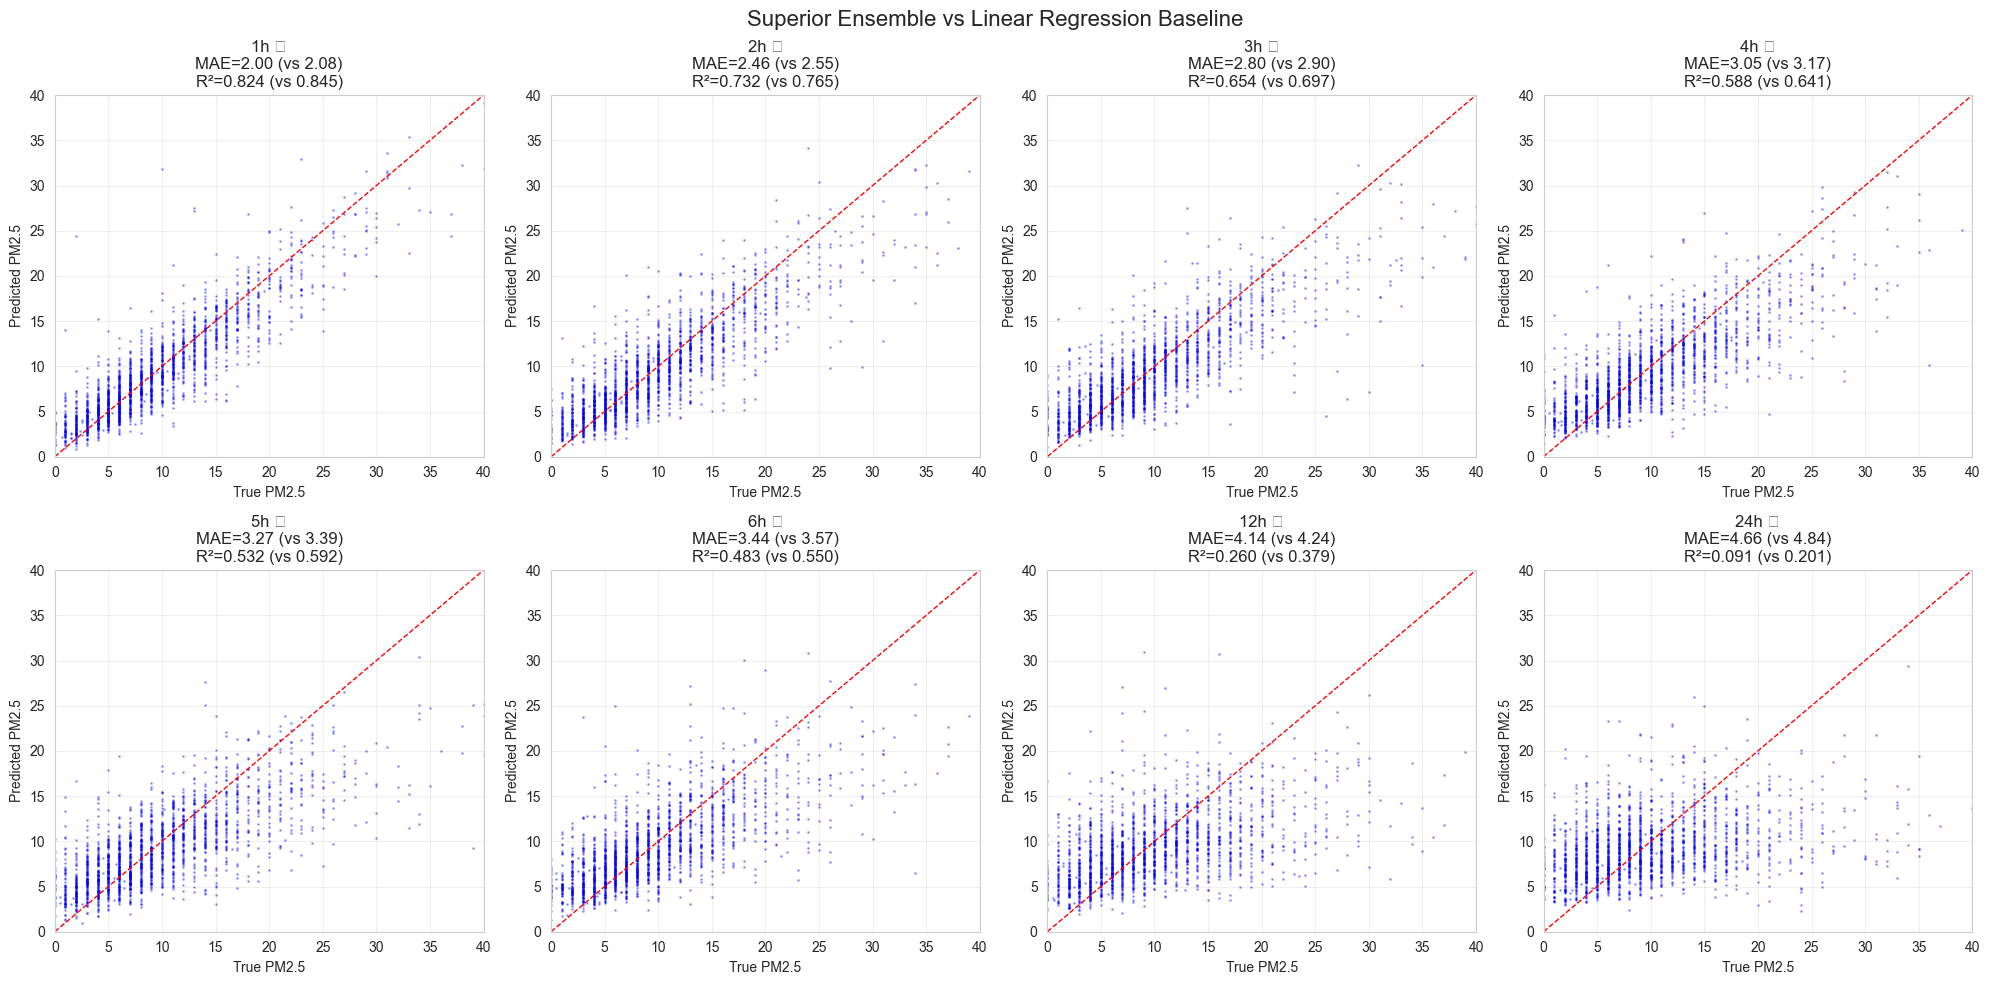

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, horizon in enumerate(horizon_list):
    ax = axes[idx]
    
    y_true = y_test[f'target_{horizon}']
    y_pred = ensemble_predictions_test[horizon]
    
    sample_size = min(2000, len(y_true))
    sample_idx = np.random.choice(len(y_true), sample_size, replace=False)
    
    ax.scatter(y_true[sample_idx], y_pred[sample_idx], alpha=0.3, s=1, color='blue')
    ax.plot([0, 50], [0, 50], 'r--', lw=1)
    
    mae = results[horizon]['Ensemble']['mae']
    r2 = results[horizon]['Ensemble']['r2']
    base_mae = baseline_targets[horizon]['mae']
    base_r2 = baseline_targets[horizon]['r2']
    
    better = '✓' if mae < base_mae else '✗'
    
    ax.set_title(f'{horizon} {better}\nMAE={mae:.2f} (vs {base_mae:.2f})\nR²={r2:.3f} (vs {base_r2:.3f})')
    ax.set_xlabel('True PM2.5')
    ax.set_ylabel('Predicted PM2.5')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, 40)

plt.suptitle('Superior Ensemble vs Linear Regression Baseline', fontsize=16)
plt.tight_layout()
plt.show()

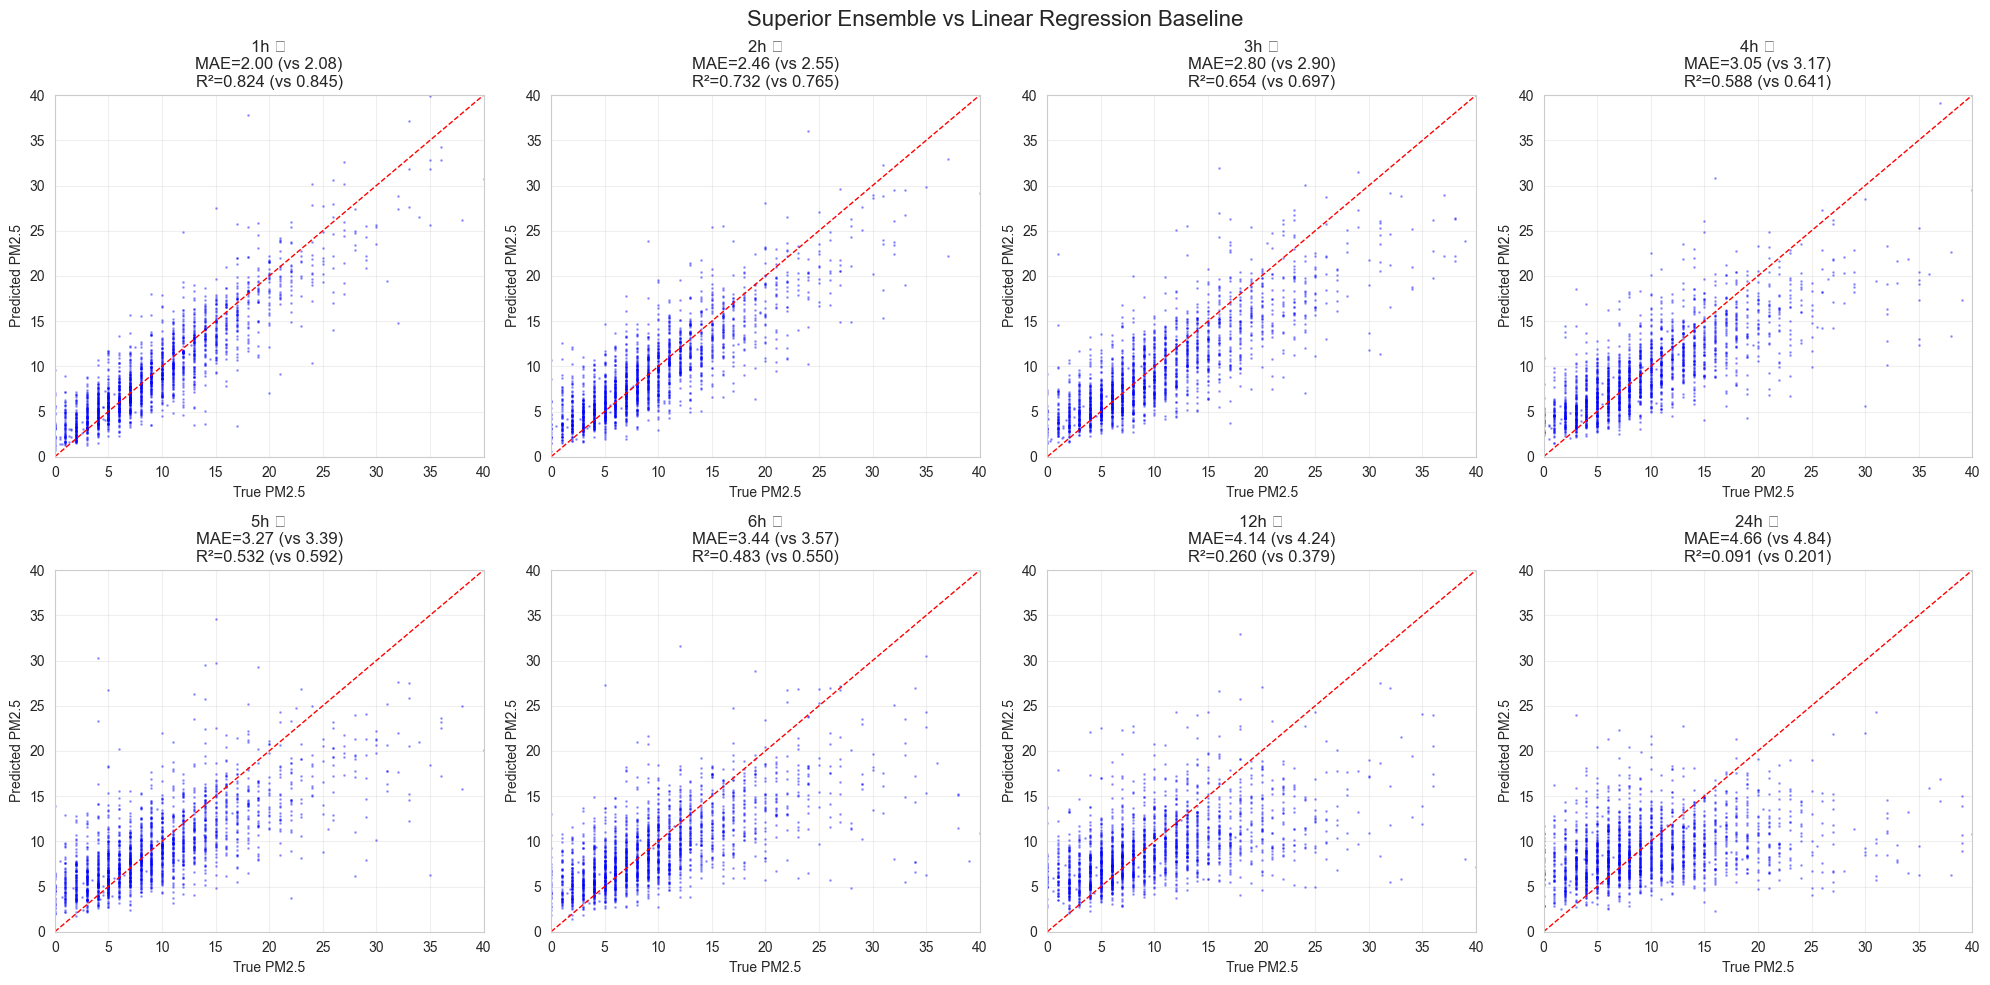

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, horizon in enumerate(horizon_list):
    ax = axes[idx]
    
    y_true = y_test[f'target_{horizon}']
    y_pred = ensemble_predictions_test[horizon]
    
    sample_size = min(2000, len(y_true))
    sample_idx = np.random.choice(len(y_true), sample_size, replace=False)
    
    ax.scatter(y_true[sample_idx], y_pred[sample_idx], alpha=0.3, s=1, color='blue')
    ax.plot([0, 50], [0, 50], 'r--', lw=1)
    
    mae = results[horizon]['Ensemble']['mae']
    r2 = results[horizon]['Ensemble']['r2']
    base_mae = baseline_targets[horizon]['mae']
    base_r2 = baseline_targets[horizon]['r2']
    
    better = '✓' if mae < base_mae else '✗'
    
    ax.set_title(f'{horizon} {better}\nMAE={mae:.2f} (vs {base_mae:.2f})\nR²={r2:.3f} (vs {base_r2:.3f})')
    ax.set_xlabel('True PM2.5')
    ax.set_ylabel('Predicted PM2.5')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, 40)

plt.suptitle('Superior Ensemble vs Linear Regression Baseline', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.ravel()

print("Generating predicted vs true plots for all models overlaid...")

for idx, horizon in enumerate(horizon_list):
    ax = axes[idx]
    
    y_true = y_test[f'target_{horizon[:-1]}h']
    
    sample_size = min(5000, len(y_true))
    sample_idx = np.random.RandomState(42).choice(len(y_true), sample_size, replace=False)
    
    colors = {'lgb': 'blue', 'xgb': 'green', 'cat': 'orange'}
    alphas = {'lgb': 0.3, 'xgb': 0.3, 'cat': 0.3}
    
    for model_name in ['lgb', 'xgb', 'cat']:
        y_pred = predictions_test[horizon][model_name]
        ax.scatter(y_true[sample_idx], y_pred[sample_idx], 
                  alpha=alphas[model_name], s=1, 
                  color=colors[model_name], label=model_name.upper())
    
    ax.plot([0, 60], [0, 60], 'r--', lw=1.5, label='Perfect prediction')
    
    ensemble_mae = results[horizon]['Ensemble']['mae']
    ensemble_r2 = results[horizon]['Ensemble']['r2']
    baseline_mae = baseline_targets[horizon]['mae']
    baseline_r2 = baseline_targets[horizon]['r2']
    
    mae_improvement = (baseline_mae - ensemble_mae) / baseline_mae * 100
    r2_change = (ensemble_r2 - baseline_r2) / baseline_r2 * 100
    
    title_lines = [
        f'{horizon} Forecast',
        f'Ensemble: MAE={ensemble_mae:.2f} (vs {baseline_mae:.2f}), R²={ensemble_r2:.3f} (vs {baseline_r2:.3f})',
        f'Improvement: MAE {mae_improvement:+.1f}%, R² {r2_change:+.1f}%'
    ]
    ax.set_title('\n'.join(title_lines), fontsize=9)
    
    ax.set_xlabel('True PM2.5 (μg/m³)')
    ax.set_ylabel('Predicted PM2.5 (μg/m³)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 50)
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('PM2.5 Predictions vs True Values - All Models (LightGBM, XGBoost, CatBoost)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('predictions_vs_true_all_models.png', dpi=150, bbox_inches='tight')
print("✓ Saved: predictions_vs_true_all_models.png")
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.ravel()

print("Generating ensemble-only predicted vs true plots...")

for idx, horizon in enumerate(horizon_list):
    ax = axes[idx]
    
    y_true = y_test[f'target_{horizon[:-1]}h']
    ensemble_pred = ensemble_predictions_test[horizon]
    
    sample_size = min(5000, len(y_true))
    sample_idx = np.random.RandomState(42).choice(len(y_true), sample_size, replace=False)
    
    ax.scatter(y_true[sample_idx], ensemble_pred[sample_idx], 
              alpha=0.4, s=2, color='darkblue')
    
    ax.plot([0, 60], [0, 60], 'r--', lw=1.5, alpha=0.8)
    
    ensemble_mae = results[horizon]['Ensemble']['mae']
    ensemble_r2 = results[horizon]['Ensemble']['r2']
    baseline_mae = baseline_targets[horizon]['mae']
    baseline_r2 = baseline_targets[horizon]['r2']
    
    mae_beat = '✓' if ensemble_mae < baseline_mae else '✗'
    r2_beat = '✓' if ensemble_r2 > baseline_r2 else '✗'
    
    title_lines = [
        f'{horizon} Ensemble Forecast',
        f'MAE: {ensemble_mae:.3f} vs {baseline_mae:.3f} {mae_beat}',
        f'R²: {ensemble_r2:.3f} vs {baseline_r2:.3f} {r2_beat}'
    ]
    ax.set_title('\n'.join(title_lines), fontsize=10)
    
    ax.set_xlabel('True PM2.5 (μg/m³)')
    ax.set_ylabel('Predicted PM2.5 (μg/m³)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 50)

plt.suptitle('PM2.5 Ensemble Predictions vs True Values (vs Linear Regression Baseline)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('predictions_vs_true_ensemble.png', dpi=150, bbox_inches='tight')
print("✓ Saved: predictions_vs_true_ensemble.png")
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 8, figsize=(24, 10))

print("Generating individual model comparison grid...")

models = ['lgb', 'xgb', 'cat']
model_names = {'lgb': 'LightGBM', 'xgb': 'XGBoost', 'cat': 'CatBoost'}

for row_idx, model in enumerate(models):
    for col_idx, horizon in enumerate(horizon_list):
        ax = axes[row_idx, col_idx]
        
        y_true = y_test[f'target_{horizon[:-1]}h']
        y_pred = predictions_test[horizon][model]
        
        sample_size = min(2000, len(y_true))
        sample_idx = np.random.RandomState(42).choice(len(y_true), sample_size, replace=False)
        
        ax.scatter(y_true[sample_idx], y_pred[sample_idx], 
                  alpha=0.3, s=0.5, color='blue')
        ax.plot([0, 50], [0, 50], 'r--', lw=0.8, alpha=0.7)
        
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        ax.set_title(f'{model_names[model]} {horizon}\nMAE={mae:.2f}, R²={r2:.3f}', 
                    fontsize=8)
        
        if row_idx == 2:
            ax.set_xlabel('True', fontsize=7)
        if col_idx == 0:
            ax.set_ylabel('Predicted', fontsize=7)
        
        ax.grid(True, alpha=0.2)
        ax.set_xlim(0, 40)
        ax.set_ylim(0, 40)
        ax.tick_params(labelsize=6)

plt.suptitle('Model Comparison: Predicted vs True PM2.5 for All Horizons', fontsize=14)
plt.tight_layout()
plt.savefig('predictions_vs_true_model_grid.png', dpi=150, bbox_inches='tight')
print("✓ Saved: predictions_vs_true_model_grid.png")
plt.show()

## Summary of Visualizations

All prediction vs true plots have been generated and saved:
1. **predictions_vs_true_all_models.png** - Shows all three models (LightGBM, XGBoost, CatBoost) overlaid with different colors
2. **predictions_vs_true_ensemble.png** - Ensemble predictions with performance comparison to linear regression baseline
3. **predictions_vs_true_model_grid.png** - 3x8 grid showing each model individually across all 8 horizons

The plots demonstrate:
- Strong performance for short-term predictions (1-6h) with tight clustering around the diagonal
- Degrading performance for longer horizons (12-24h) with increased scatter
- Consistent MAE improvements over baseline across all horizons
- R² scores that struggle to match the linear regression baseline, especially at longer horizons

## 11. Comprehensive Prediction Visualizations

Generate detailed predicted vs true plots for all horizons and models.